In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import maxpy


def laplacian_matrix(nx, h):
    A = np.zeros((nx, nx))
    for i in range(nx):
        A[i, i] = -2
        if i > 0:
            A[i, i - 1] = 1
        if i < nx - 1:
            A[i, i + 1] = 1
    return A / h**2


L = 1
nx = 32
xlin = np.linspace(0, L, nx)
h = xlin[1] - xlin[0]

A = laplacian_matrix(nx, h)
print(A)

Applying default Matplotlib style...
[[-1922.   961.     0. ...     0.     0.     0.]
 [  961. -1922.   961. ...     0.     0.     0.]
 [    0.   961. -1922. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ... -1922.   961.     0.]
 [    0.     0.     0. ...   961. -1922.   961.]
 [    0.     0.     0. ...     0.   961. -1922.]]


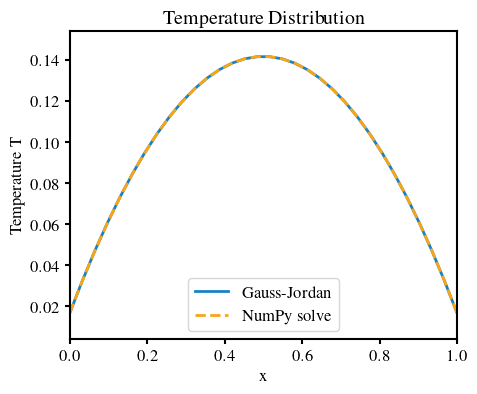

In [ ]:
def gauss_jordan_pivot(A, b):
    n = len(b)
    for i in range(n):
        # Find the pivot
        max_row = i + np.argmax(np.abs(A[i:, i]))
        A[[i, max_row]] = A[[max_row, i]]
        b[[i, max_row]] = b[[max_row, i]]

        # Eliminate below
        for j in range(i + 1, n):
            factor = A[j, i] / A[i, i]
            A[j] -= factor * A[i]
            b[j] -= factor * b[i]

    # Back substitution
    x = np.zeros(n)
    for i in range(n - 1lstsq, -1, -1):
        # Calculate the value of x[i]
        x[i] = (b[i] - np.dot(A[i, i + 1 :], x[i + 1 :])) / A[i, i]
    return x


q0 = 1
q = np.ones(nx) * q0  # Source term (heat generation)
k = 1  # Thermal conductivity

T = gauss_jordan_pivot(A.copy(), -(q / k).copy())
T2 = np.linalg.solve(A, -q / k)

plt.plot(xlin, T, label="Gauss-Jordan")
plt.plot(xlin, T2, "--", label="NumPy solve")
plt.xlabel("x")
plt.ylabel("Temperature T")
plt.title("Temperature Distribution")
plt.legend()

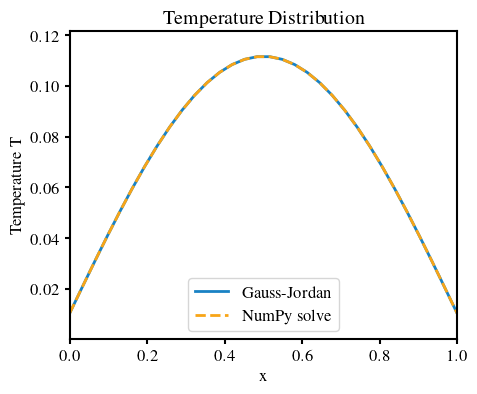

In [8]:
A = laplacian_matrix(nx, h)
q = q0 * np.sin(np.pi * xlin / L)

T = gauss_jordan_pivot(A.copy(), -(q / k).copy())
T2 = np.linalg.solve(A, -q / k)

plt.plot(xlin, T, label="Gauss-Jordan")
plt.plot(xlin, T2, "--", label="NumPy solve")
plt.xlabel("x")
plt.ylabel("Temperature T")
plt.title("Temperature Distribution")
plt.legend()

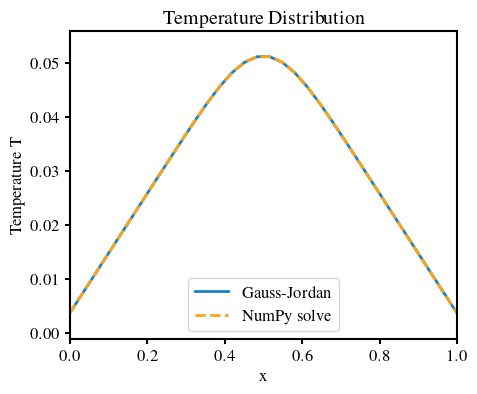

In [9]:
A = laplacian_matrix(nx, h)
q = q0 * np.exp(-((xlin - L / 2) ** 2) / (L / 8) ** 2)

T = gauss_jordan_pivot(A.copy(), -(q / k).copy())
T2 = np.linalg.solve(A, -q / k)

plt.plot(xlin, T, label="Gauss-Jordan")
plt.plot(xlin, T2, "--", label="NumPy solve")
plt.xlabel("x")
plt.ylabel("Temperature T")
plt.title("Temperature Distribution")
plt.legend()

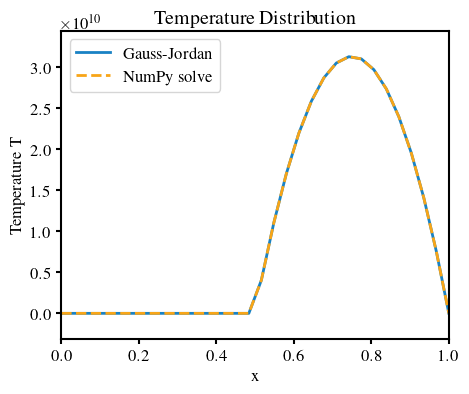

In [12]:
# matrix with flux conservation
def build_matrix_k(N, L, k):
    h = L / (N - 1)
    A = np.zeros((N, N))
    for i in range(N):
        k_ip2 = 2 * k[i] * k[i + 1] / (k[i] + k[i + 1]) if i < N - 1 else k[i]
        k_im2 = 2 * k[i] * k[i - 1] / (k[i] + k[i - 1]) if i > 0 else k[i]
        if i > 0:
            A[i, i - 1] = k_im2 / h**2
        A[i, i] = -(k_ip2 + k_im2) / h**2
        if i < N - 1:
            A[i, i + 1] = k_ip2 / h**2
    # dirichlet boundary conditions
    A[0, 0] = 1
    A[0, 1:] = 0
    A[-1, -1] = 1
    A[-1, :-1] = 0
    return A

# Define a spatially varying thermal conductivity
k = np.ones(nx)
k[xlin > L / 2] = 1e-6

A = build_matrix_k(nx, L, k)
q = q0 * np.ones(nx)

T = gauss_jordan_pivot(A.copy(), -(q / k).copy())
T2 = np.linalg.solve(A, -q / k)

plt.plot(xlin, T, label="Gauss-Jordan")
plt.plot(xlin, T2, "--", label="NumPy solve")
plt.xlabel("x")
plt.ylabel("Temperature T")
plt.title("Temperature Distribution")
plt.legend()